이상 데이터 추출

In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

BASE_DIR = Path('/content/drive/MyDrive/dataminig')

Mounted at /content/drive


In [3]:
df_test = pd.read_csv(BASE_DIR / 'data' / 'processed' / 'test_features.csv')
df_train = pd.read_csv(BASE_DIR / 'data' / 'processed' / 'train_features.csv')
df_valid = pd.read_csv(BASE_DIR / 'data' / 'processed' / 'valid_features.csv')

In [4]:
#3개의 df 각각 전처리

feature_cols = [
    "vol_chg_rate",
    "volume_ma20_ratio",
    "daily_return",
    "volatility_5d",
    "drawdown_after_peak_5d",
    "upper_shadow_ratio",
    "body_ratio",
    "upper_shadow_streak_5d"
]

# 1. inf 값을 NaN으로 바꾸기
df_test = df_test.replace([np.inf, -np.inf], np.nan)
df_train = df_train.replace([np.inf, -np.inf], np.nan)
df_valid = df_valid.replace([np.inf, -np.inf], np.nan)

# 2. feature 컬럼 기준 결측치 제거
df_test = df_test.dropna(subset=feature_cols).copy()
df_train = df_train.dropna(subset=feature_cols).copy()
df_valid = df_valid.dropna(subset=feature_cols).copy()

# 3. 너무 큰 값 잘라내기: 극단값 완화
'''for col in feature_cols:
    lower = df_test[col].quantile(0.01)
    upper = df_test[col].quantile(0.99)
    df_test[col] = df_test[col].clip(lower, upper)
    lower = df_train[col].quantile(0.01)
    upper = df_train[col].quantile(0.99)
    df_train[col] = df_train[col].clip(lower, upper)
    lower = df_valid[col].quantile(0.01)
    upper = df_valid[col].quantile(0.99)
    df_valid[col] = df_valid[col].clip(lower, upper)'''

# 4. X 생성
X_test = df_test[feature_cols].copy()
X_train = df_train[feature_cols].copy()
X_valid = df_valid[feature_cols].copy()
print("test dataset 전처리 완료 및 크기")
print(X_test.isna().sum())
print(np.isinf(X_test).sum())
print(X_test.shape)
print("train dataset 전처리 완료 및 크기")
print(X_train.isna().sum())
print(np.isinf(X_train).sum())
print(X_train.shape)
print("validation dataset 전처리 완료 및 크기")
print(X_valid.isna().sum())
print(np.isinf(X_valid).sum())
print(X_valid.shape)

test dataset 전처리 완료 및 크기
vol_chg_rate              0
volume_ma20_ratio         0
daily_return              0
volatility_5d             0
drawdown_after_peak_5d    0
upper_shadow_ratio        0
body_ratio                0
upper_shadow_streak_5d    0
dtype: int64
vol_chg_rate              0
volume_ma20_ratio         0
daily_return              0
volatility_5d             0
drawdown_after_peak_5d    0
upper_shadow_ratio        0
body_ratio                0
upper_shadow_streak_5d    0
dtype: int64
(3709, 8)
train dataset 전처리 완료 및 크기
vol_chg_rate              0
volume_ma20_ratio         0
daily_return              0
volatility_5d             0
drawdown_after_peak_5d    0
upper_shadow_ratio        0
body_ratio                0
upper_shadow_streak_5d    0
dtype: int64
vol_chg_rate              0
volume_ma20_ratio         0
daily_return              0
volatility_5d             0
drawdown_after_peak_5d    0
upper_shadow_ratio        0
body_ratio                0
upper_shadow_streak_5d    0
dtyp

In [5]:
df_train_scaled = df_train.copy()
df_test_scaled = df_test.copy()
df_valid_scaled = df_valid.copy()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(df_train[feature_cols])
df_train_scaled[feature_cols] = scaler.transform(df_train[feature_cols])
df_test_scaled[feature_cols] = scaler.transform(df_test[feature_cols])
df_valid_scaled[feature_cols] = scaler.transform(df_valid[feature_cols])

X_test_scaled = df_test_scaled[feature_cols].copy()
X_train_scaled = df_train_scaled[feature_cols].copy()
X_valid_scaled = df_valid_scaled[feature_cols].copy()

X_train_scaled.head()

,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
0,-0.004672,-0.272145,-0.176958,-0.949109,-0.479404,-0.622076,-0.616739,0.526118
1,0.021993,0.773289,-1.012771,-0.575285,0.180069,-0.786043,0.842371,0.526118
2,-0.024939,0.044071,0.600011,-0.329513,-0.418817,-0.760537,1.591810,-0.433482
3,-0.036109,-0.872873,0.434946,-0.239137,-0.804684,-0.699960,0.167877,-1.393083
4,0.024305,-0.627681,-0.556045,-0.174120,-0.579977,-0.699960,1.083262,-1.393083


In [6]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)
iso_model.fit(X_train_scaled)

#이상치 점수
df_train_scaled["anomaly_score"] = -iso_model.decision_function(X_train_scaled)
df_test_scaled["anomaly_score"] = -iso_model.decision_function(X_test_scaled)
df_valid_scaled["anomaly_score"] = -iso_model.decision_function(X_valid_scaled)
#label명 바꾸기 (정상:1, 이상치:-1) => (정상:0, 이상치:1)
df_train_scaled["anomaly_label"] = iso_model.predict(X_train_scaled)
df_train_scaled["anomaly_label"] = df_train_scaled["anomaly_label"].map({1: 0, -1: 1})
df_test_scaled["anomaly_label"] = iso_model.predict(X_test_scaled)
df_test_scaled["anomaly_label"] = df_test_scaled["anomaly_label"].map({1: 0, -1: 1})
df_valid_scaled["anomaly_label"] = iso_model.predict(X_valid_scaled)
df_valid_scaled["anomaly_label"] = df_valid_scaled["anomaly_label"].map({1: 0, -1: 1})

#정상 데이터와 이상 데이터 개수 표시
df_test_scaled["anomaly_label"].value_counts()

,count
anomaly_label,
0,3474
1,235


In [7]:
df_test_scaled.head()

,date,adj_close,close,high,low,open,volume,ticker,group,prev_volume,...,volume_ma20_ratio,prev_close,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d,anomaly_score,anomaly_label
0,2026-03-26,16540.0,16540.0,16780.0,16430.0,16780.0,118977,000080.KS,Medium,110810.0,...,-0.468867,16660.0,-0.266962,-0.417282,-0.698558,-1.245152,0.847877,0.526118,-0.170148,0
1,2026-03-27,16730.0,16730.0,16740.0,16330.0,16510.0,132871,000080.KS,Medium,118977.0,...,-0.383525,16540.0,0.358804,-0.366856,-1.007658,-1.138773,0.301836,-0.433482,-0.178141,0
2,2026-03-30,16470.0,16470.0,16700.0,16350.0,16430.0,83695,000080.KS,Medium,132871.0,...,-0.600298,16730.0,-0.546129,-0.426909,-0.624398,1.621000,-1.244432,-0.433482,-0.135851,0
3,2026-03-31,16720.0,16720.0,17090.0,16400.0,16410.0,276697,000080.KS,Medium,83695.0,...,0.348960,16470.0,0.482410,-0.563636,-0.545847,1.093642,-0.017854,0.526118,-0.126598,0
4,2026-04-01,16920.0,16920.0,17010.0,16610.0,16990.0,242884,000080.KS,Medium,276697.0,...,0.253682,16720.0,0.374688,-0.516210,-0.835315,-1.027075,-1.022124,0.526118,-0.162956,0


In [8]:
#이상치 점수가 가장 높은 30개의 데이터 확인
top_anomaly = (
    df_train_scaled
    .sort_values("anomaly_score", ascending=False)
    .head(30)
)

top_anomaly[[
    "date",
    "ticker",
    "anomaly_score",
    "vol_chg_rate",
    "volume_ma20_ratio",
    "volatility_5d",
    "upper_shadow_ratio"
]]

,date,ticker,anomaly_score,vol_chg_rate,volume_ma20_ratio,volatility_5d,upper_shadow_ratio
18556,2025-04-30,021040.KQ,0.222062,1.016411,15.219839,9.748624,2.425447
33576,2025-03-21,058450.KQ,0.215323,1.215756,14.780497,5.598994,-1.245152
26594,2024-08-14,037350.KQ,0.203785,3.885091,15.071752,5.857103,-1.245152
37782,2025-09-01,083660.KQ,0.201511,0.490078,4.780458,6.510630,-1.195476
36415,2025-09-02,073540.KS,0.200554,1.666798,11.427717,6.473883,-1.245152
34013,2025-03-06,060230.KQ,0.200504,0.806346,11.610783,4.515115,-1.093447
37643,2025-02-07,083660.KQ,0.196777,7.420169,17.106853,5.869447,-1.245152
33869,2024-07-16,060230.KQ,0.193905,0.656913,5.954454,7.071701,1.105376
18645,2025-09-10,021040.KQ,0.191550,7.388654,17.071710,4.159502,-0.290746
33310,2024-02-14,058450.KQ,0.191204,1.309369,14.701497,2.814286,1.676254


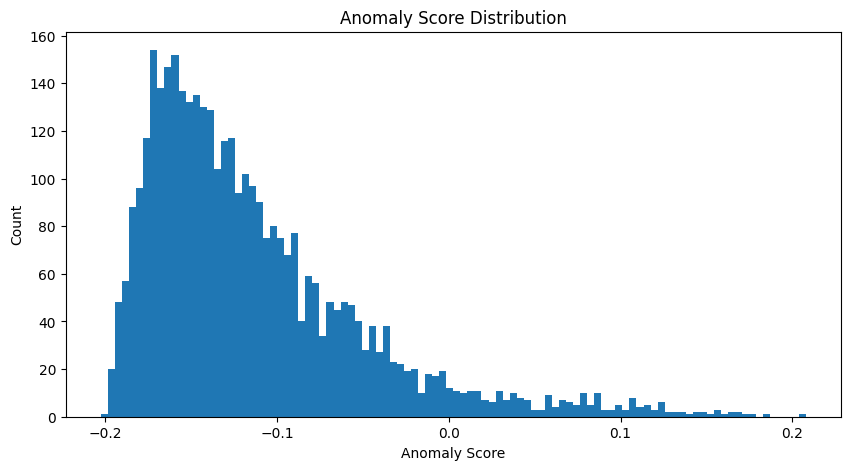

In [9]:
#이상치 점수 분포 확인
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df_test_scaled["anomaly_score"], bins=100)

plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Count")
plt.savefig('Anomaly Score Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

이상 데이터 분리 후 클러스터링

In [10]:
#이상 데이터만 따로 분류
anomaly_train_df = df_train_scaled[
    df_train_scaled["anomaly_label"] == 1
].copy()

anomaly_test_df = df_test_scaled[
    df_test_scaled["anomaly_label"] == 1
].copy()

anomaly_valid_df = df_valid_scaled[
    df_valid_scaled["anomaly_label"] == 1
].copy()

In [11]:
#클러스터링에 사용할 feature들

cluster_feature_cols = [
    "vol_chg_rate",
    "volume_ma20_ratio",
    "daily_return",
    "volatility_5d",
    "drawdown_after_peak_5d",
    "upper_shadow_ratio",
    "body_ratio",
    "upper_shadow_streak_5d"
]

X_train_cluster = anomaly_train_df[cluster_feature_cols].copy()
X_test_cluster = anomaly_test_df[cluster_feature_cols].copy()
X_valid_cluster = anomaly_valid_df[cluster_feature_cols].copy()

#클러스터링 전 전처리: 무한대 값 및 결측치 포함된 행 제거
X_train_cluster = X_train_cluster.replace([np.inf, -np.inf], np.nan)
X_train_cluster = X_train_cluster.dropna()
X_test_cluster = X_test_cluster.replace([np.inf, -np.inf], np.nan)
X_test_cluster = X_test_cluster.dropna()
X_valid_cluster = X_valid_cluster.replace([np.inf, -np.inf], np.nan)
X_valid_cluster = X_valid_cluster.dropna()

# anomaly_df도 X_cluster 인덱스에 맞추기
anomaly_train_df = anomaly_train_df.loc[X_train_cluster.index].copy()
anomaly_test_df = anomaly_test_df.loc[X_test_cluster.index].copy()
anomaly_valid_df = anomaly_valid_df.loc[X_valid_cluster.index].copy()

print(X_train_cluster.shape)

(1269, 8)


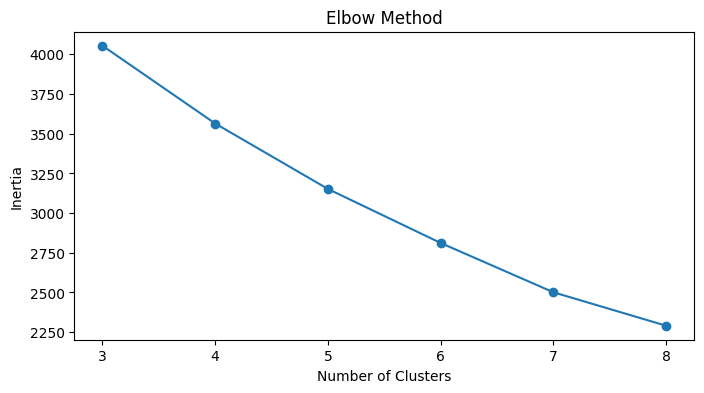

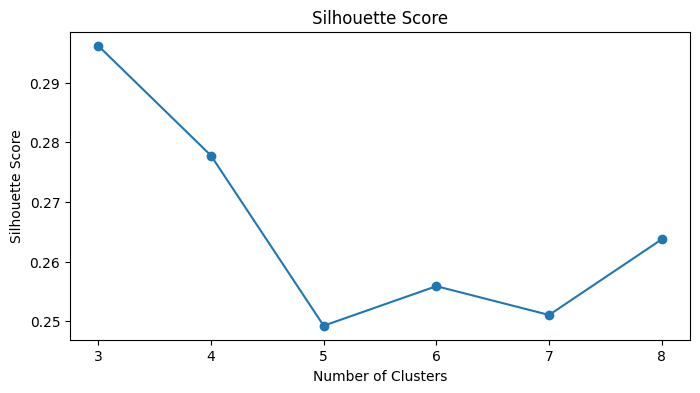

,k,inertia,silhouette
0,3,4054.291118,0.296219
1,4,3564.327491,0.277790
2,5,3152.215131,0.249222
3,6,2811.978481,0.255860
4,7,2501.426343,0.251027
5,8,2290.721522,0.263735


In [12]:
#K-Means 수행 전 K 설정 위한 inertia, silhouette score 확인
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouette_scores = []

K_range = range(3, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_valid_cluster)

    inertias.append(kmeans.inertia_)


    silhouette_scores.append(silhouette_score(X_valid_cluster, labels))


plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.savefig('Elbow Method.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), silhouette_scores, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.savefig('Silhouette .png', dpi=300, bbox_inches='tight')
plt.show()

pd.DataFrame({
    "k": list(K_range),
    "inertia": inertias,
    "silhouette": silhouette_scores
})

In [13]:
#k=3으로 설정 후 K-Means 진행

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_train_cluster)
anomaly_test_df["cluster"] = kmeans.predict(X_test_cluster)

anomaly_test_df["cluster"].value_counts().sort_index()

,count
cluster,
0,144
1,91


In [14]:
#클러스터 별 feature 평균값 확인
anomaly_train_df["cluster"] = kmeans.predict(X_train_cluster)
cluster_profile = (
    anomaly_train_df
    .groupby("cluster")[cluster_feature_cols]
    .mean()
)

cluster_profile

,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,0.053981,1.058051,-1.784019,3.748434,3.833039,0.069623,0.294464,0.192559
1,0.342378,5.005102,3.359361,2.028532,0.162600,0.173592,0.466452,0.159955
2,203.445155,2.273167,1.999809,0.430702,-0.204512,0.640157,0.274180,0.526118


In [15]:
#평균값 표준화 시킨 후 재확인
scaler2 = StandardScaler()
scaler2.fit(X_train_cluster)

cluster_profile_scaled = pd.DataFrame(
    scaler2.transform(cluster_profile),
    columns=cluster_feature_cols,
    index=cluster_profile.index
)

cluster_profile_scaled

,vol_chg_rate,volume_ma20_ratio,daily_return,volatility_5d,drawdown_after_peak_5d,upper_shadow_ratio,body_ratio,upper_shadow_streak_5d
cluster,,,,,,,,
0,-0.054817,-0.588343,-0.778145,0.370787,0.809932,-0.045913,-0.082043,0.015196
1,-0.004745,0.502697,0.663968,-0.315186,-0.690292,0.038590,0.070195,-0.013425
2,35.258799,-0.252462,0.282774,-0.952472,-0.840342,0.417800,-0.099998,0.308008


In [16]:
#클러스터별 주요 특징
for cluster_id in sorted(anomaly_train_df["cluster"].unique()):
    print(f"\n===== Cluster {cluster_id} 주요 특징 =====")

    row = cluster_profile_scaled.loc[cluster_id].sort_values(ascending=False)
    print(row.head(5))


===== Cluster 0 주요 특징 =====
drawdown_after_peak_5d    0.809932
volatility_5d             0.370787
upper_shadow_streak_5d    0.015196
upper_shadow_ratio       -0.045913
vol_chg_rate             -0.054817
Name: 0, dtype: float64

===== Cluster 1 주요 특징 =====
daily_return          0.663968
volume_ma20_ratio     0.502697
body_ratio            0.070195
upper_shadow_ratio    0.038590
vol_chg_rate         -0.004745
Name: 1, dtype: float64

===== Cluster 2 주요 특징 =====
vol_chg_rate              35.258799
upper_shadow_ratio         0.417800
upper_shadow_streak_5d     0.308008
daily_return               0.282774
body_ratio                -0.099998
Name: 2, dtype: float64


In [17]:
anomaly_test_df.to_csv("anomaly_cluster_result.csv", index=False, encoding="utf-8-sig")
cluster_profile.to_csv("cluster_profile_raw.csv", encoding="utf-8-sig")
cluster_profile_scaled.to_csv("cluster_profile_scaled.csv", encoding="utf-8-sig")